In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r".\Datasets\Auto-MPG-Dataset\auto-mpg.data", delim_whitespace = True, header = None)
df

,0,1,2,3,4,5,6,7,8
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [3]:
df.columns = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.00,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.00,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.00,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.00,2625.0,18.6,82,1,ford ranger


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [5]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [6]:
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower       object
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

In [7]:
for i in df.columns: print(i,":\n",df[i].unique())

mpg :
 [18.  15.  16.  17.  14.  24.  22.  21.  27.  26.  25.  10.  11.   9.
 28.  19.  12.  13.  23.  30.  31.  35.  20.  29.  32.  33.  17.5 15.5
 14.5 22.5 24.5 18.5 29.5 26.5 16.5 31.5 36.  25.5 33.5 20.5 30.5 21.5
 43.1 36.1 32.8 39.4 19.9 19.4 20.2 19.2 25.1 20.6 20.8 18.6 18.1 17.7
 27.5 27.2 30.9 21.1 23.2 23.8 23.9 20.3 21.6 16.2 19.8 22.3 17.6 18.2
 16.9 31.9 34.1 35.7 27.4 25.4 34.2 34.5 31.8 37.3 28.4 28.8 26.8 41.5
 38.1 32.1 37.2 26.4 24.3 19.1 34.3 29.8 31.3 37.  32.2 46.6 27.9 40.8
 44.3 43.4 36.4 44.6 40.9 33.8 32.7 23.7 23.6 32.4 26.6 25.8 23.5 39.1
 39.  35.1 32.3 37.7 34.7 34.4 29.9 33.7 32.9 31.6 28.1 30.7 24.2 22.4
 34.  38.  44. ]
cylinders :
 [8 4 6 3 5]
displacement :
 [307.  350.  318.  304.  302.  429.  454.  440.  455.  390.  383.  340.
 400.  113.  198.  199.  200.   97.  110.  107.  104.  121.  360.  140.
  98.  232.  225.  250.  351.  258.  122.  116.   79.   88.   71.   72.
  91.   97.5  70.  120.   96.  108.  155.   68.  114.  156.   76.   83.
  90.  23

In [8]:
df.horsepower.unique()

array(['130.0', '165.0', '150.0', '140.0', '198.0', '220.0', '215.0',
       '225.0', '190.0', '170.0', '160.0', '95.00', '97.00', '85.00',
       '88.00', '46.00', '87.00', '90.00', '113.0', '200.0', '210.0',
       '193.0', '?', '100.0', '105.0', '175.0', '153.0', '180.0', '110.0',
       '72.00', '86.00', '70.00', '76.00', '65.00', '69.00', '60.00',
       '80.00', '54.00', '208.0', '155.0', '112.0', '92.00', '145.0',
       '137.0', '158.0', '167.0', '94.00', '107.0', '230.0', '49.00',
       '75.00', '91.00', '122.0', '67.00', '83.00', '78.00', '52.00',
       '61.00', '93.00', '148.0', '129.0', '96.00', '71.00', '98.00',
       '115.0', '53.00', '81.00', '79.00', '120.0', '152.0', '102.0',
       '108.0', '68.00', '58.00', '149.0', '89.00', '63.00', '48.00',
       '66.00', '139.0', '103.0', '125.0', '133.0', '138.0', '135.0',
       '142.0', '77.00', '62.00', '132.0', '84.00', '64.00', '74.00',
       '116.0', '82.00'], dtype=object)

In [9]:
df.horsepower.to_string().count('?')

6

In [10]:
df.horsepower.mode()

0    150.0
Name: horsepower, dtype: object

In [11]:
for i in ['horsepower']: df.replace(['?'], df.horsepower.mode(), inplace = True)

In [12]:
df.horsepower.to_string().split("\n")

['0      130.0',
 '1      165.0',
 '2      150.0',
 '3      150.0',
 '4      140.0',
 '5      198.0',
 '6      220.0',
 '7      215.0',
 '8      225.0',
 '9      190.0',
 '10     170.0',
 '11     160.0',
 '12     150.0',
 '13     225.0',
 '14     95.00',
 '15     95.00',
 '16     97.00',
 '17     85.00',
 '18     88.00',
 '19     46.00',
 '20     87.00',
 '21     90.00',
 '22     95.00',
 '23     113.0',
 '24     90.00',
 '25     215.0',
 '26     200.0',
 '27     210.0',
 '28     193.0',
 '29     88.00',
 '30     90.00',
 '31     95.00',
 '32     150.0',
 '33     100.0',
 '34     105.0',
 '35     100.0',
 '36     88.00',
 '37     100.0',
 '38     165.0',
 '39     175.0',
 '40     153.0',
 '41     150.0',
 '42     180.0',
 '43     170.0',
 '44     175.0',
 '45     110.0',
 '46     72.00',
 '47     100.0',
 '48     88.00',
 '49     86.00',
 '50     90.00',
 '51     70.00',
 '52     76.00',
 '53     65.00',
 '54     69.00',
 '55     60.00',
 '56     70.00',
 '57     95.00',
 '58     80.00

In [13]:
df.horsepower.to_string().count('?')

0

In [14]:
df.horsepower = df.horsepower.astype(float)
df.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight          float64
acceleration    float64
model_year        int64
origin            int64
car_name         object
dtype: object

In [15]:
df1 = df.drop(['car_name'], axis = 1)
df1

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1


In [16]:
df_corr = df1.corr()
df_corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
mpg,1.000000,-0.775396,-0.804203,-0.753177,-0.831741,0.420289,0.579267,0.563450
cylinders,-0.775396,1.000000,0.950721,0.818454,0.896017,-0.505419,-0.348746,-0.562543
displacement,-0.804203,0.950721,1.000000,0.873330,0.932824,-0.543684,-0.370164,-0.609409
horsepower,-0.753177,0.818454,0.873330,1.000000,0.841770,-0.665833,-0.397772,-0.454271
weight,-0.831741,0.896017,0.932824,0.841770,1.000000,-0.417457,-0.306564,-0.581024
acceleration,0.420289,-0.505419,-0.543684,-0.665833,-0.417457,1.000000,0.288137,0.205873
model_year,0.579267,-0.348746,-0.370164,-0.397772,-0.306564,0.288137,1.000000,0.180662
origin,0.563450,-0.562543,-0.609409,-0.454271,-0.581024,0.205873,0.180662,1.000000


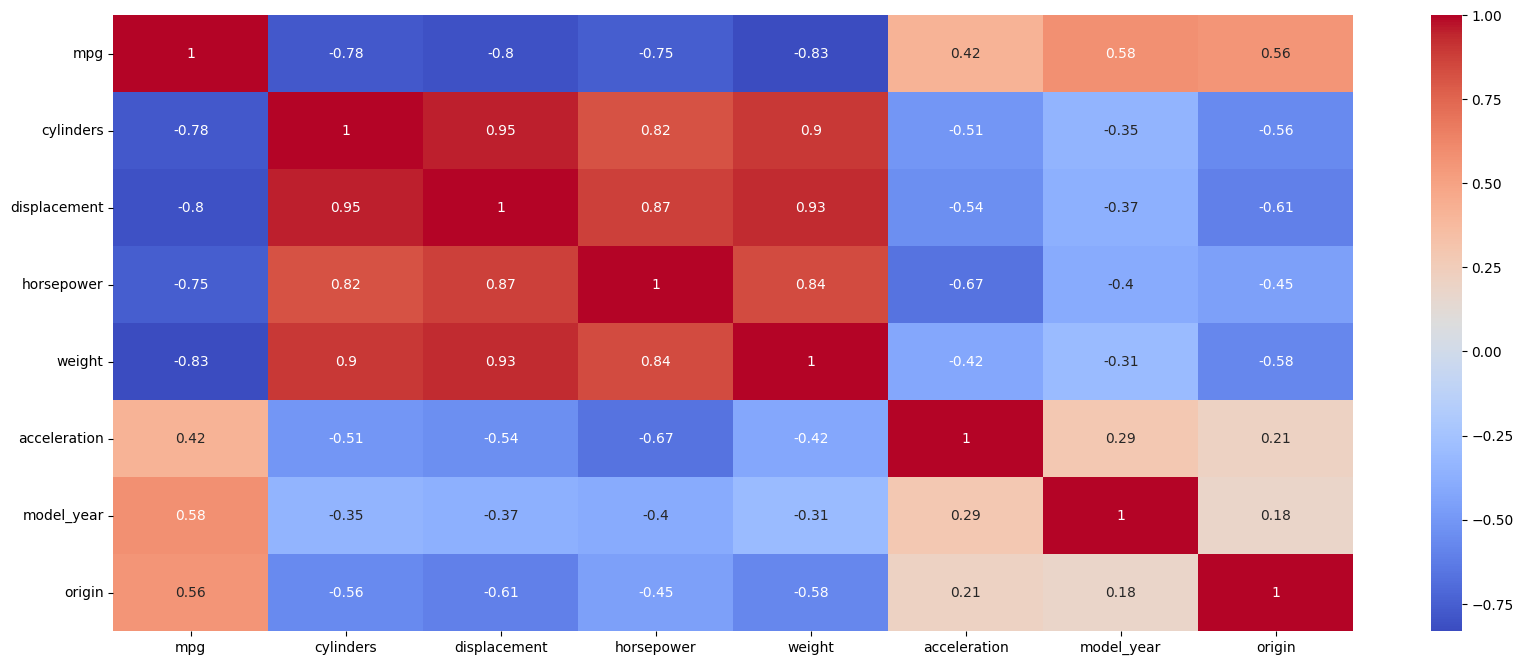

In [17]:
plt.figure(figsize = (20,8))
sns.heatmap(df_corr, annot = True, cmap = 'coolwarm')
plt.yticks(rotation = 0)
plt.show()

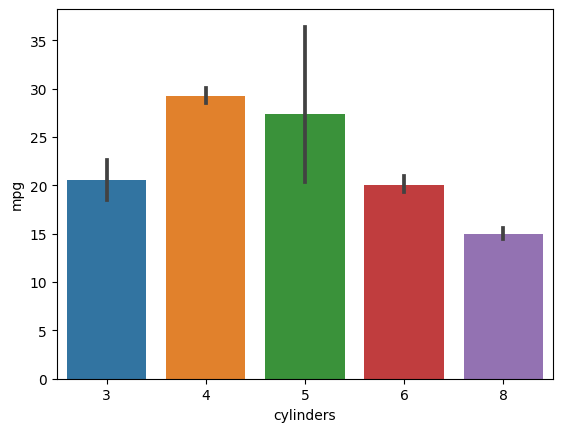

In [18]:
sns.barplot(data = df, x = 'cylinders', y = 'mpg')
plt.show()

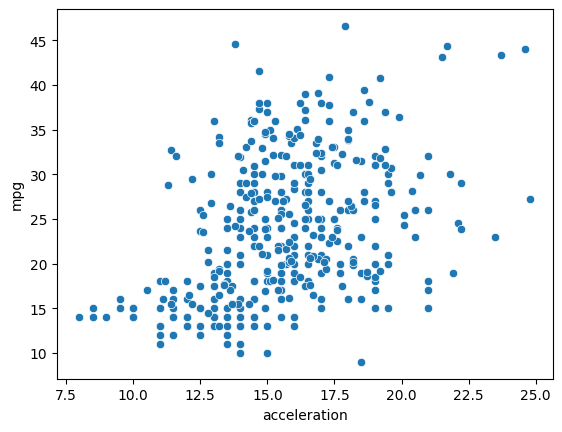

In [19]:
sns.scatterplot(x = df.acceleration, y = df.mpg)
plt.show()

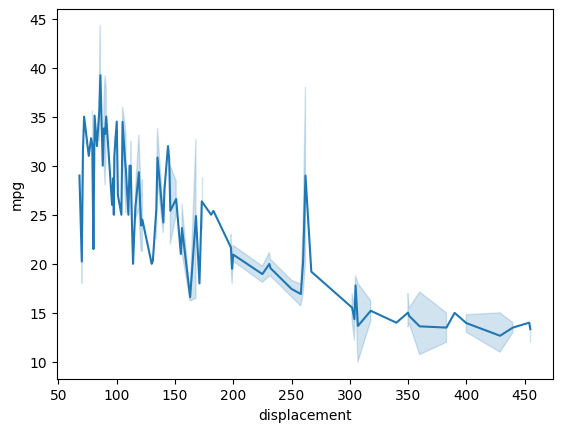

In [20]:
sns.lineplot(data = df, x = df.displacement, y = df.mpg)
plt.show()

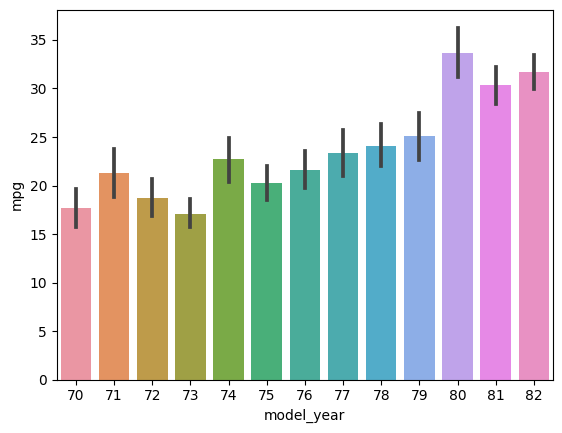

In [21]:
sns.barplot(data = df, x = 'model_year', y = 'mpg')
plt.show()

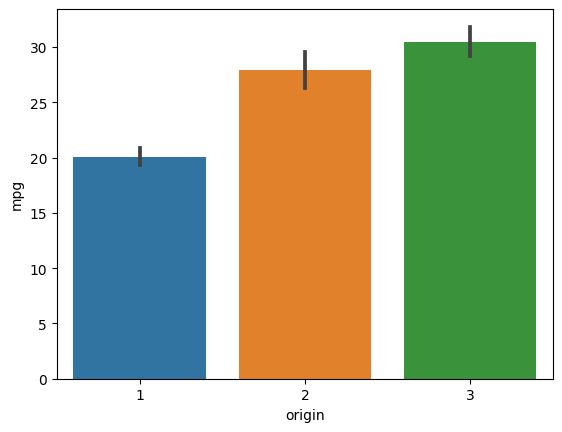

In [22]:
sns.barplot(data = df, x = 'origin', y = 'mpg')
plt.show()

In [23]:
ip = df1.drop(['mpg'], axis = 1)
ip

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,8,307.0,130.0,3504.0,12.0,70,1
1,8,350.0,165.0,3693.0,11.5,70,1
2,8,318.0,150.0,3436.0,11.0,70,1
3,8,304.0,150.0,3433.0,12.0,70,1
4,8,302.0,140.0,3449.0,10.5,70,1
...,...,...,...,...,...,...,...
393,4,140.0,86.0,2790.0,15.6,82,1
394,4,97.0,52.0,2130.0,24.6,82,2
395,4,135.0,84.0,2295.0,11.6,82,1
396,4,120.0,79.0,2625.0,18.6,82,1


In [24]:
op = df1['mpg']
op

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64

In [25]:
x_train, x_test, y_train, y_test = train_test_split(ip, op, train_size = 0.8)

In [26]:
df1.shape, x_train.shape, x_test.shape

((398, 8), (318, 7), (80, 7))

In [27]:
sc = StandardScaler()
sc

StandardScaler()

In [28]:
x_train = sc.fit_transform(x_train)
x_train

array([[-0.85013543, -0.76606469, -0.26978482, ..., -0.21254377,
        -1.61082017,  1.7291107 ],
       [-0.85013543, -0.68915591, -0.65798197, ..., -0.21254377,
         0.80541008, -0.74215763],
       [ 0.32271952, -0.35267998,  0.06665272, ..., -0.03316766,
         0.        ,  1.7291107 ],
       ...,
       [-0.85013543, -0.99679104, -1.12381856, ..., -0.1049181 ,
         1.07388011,  0.49347654],
       [ 1.49557448,  1.09897331,  0.63600855, ..., -0.57129599,
        -1.07388011, -0.74215763],
       [-0.85013543, -0.91988226, -0.70974159, ...,  0.07445801,
         1.07388011,  0.49347654]])

In [29]:
x_test = sc.fit_transform(x_test)
x_test

array([[-0.8815795 , -0.53910253, -0.31656613, -0.09742247,  0.35505679,
         1.66977462, -0.61067414],
       [ 1.50914456,  1.46930694,  1.85716615,  1.50813888, -0.94474734,
        -0.85593489, -0.61067414],
       [ 1.50914456,  1.94749967,  1.20242751,  1.98135696, -1.32704267,
        -0.85593489, -0.61067414],
       [ 0.31378253,  0.01560104, -0.2379975 ,  0.2106893 ,  0.39328632,
        -0.5753005 , -0.61067414],
       [ 1.50914456,  1.94749967,  2.25000934,  1.80065005, -1.2505836 ,
         0.26660267, -0.61067414],
       [-0.8815795 , -0.94078442, -0.94511523, -1.04645873,  0.43151585,
         0.54723706,  2.03007891],
       [ 0.31378253,  0.51292148,  0.02389796,  0.53700177, -0.37130434,
        -0.01403172, -0.61067414],
       [-0.8815795 , -0.94078442, -1.02368386, -0.72794656,  1.99892671,
         1.38914023, -0.61067414],
       [ 0.31378253,  0.34077209, -0.36894522,  0.35109467,  0.66089305,
         0.54723706, -0.61067414],
       [-0.8815795 , -0.7112

In [30]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [31]:
ycap = lr.predict(x_test)
ycap

array([27.80358244, 12.64211624, 10.81025333, 19.91325751, 14.96168069,
       32.88244901, 20.28183419, 30.86055574, 23.1666395 , 23.44872257,
       29.16246009, 19.01605772, 25.63706007, 32.7335674 , 31.84772331,
       28.63885187,  9.11189729, 31.05825837, 32.22992114, 17.32960897,
       27.35499568, 24.18642987, 36.78202587, 22.39409114, 14.49469456,
       31.29710669, 29.86273906, 24.66872916, 24.93311682, 29.487677  ,
       31.15060073, 25.14979306, 24.13423078, 22.14631751, 25.7103947 ,
       26.94651132, 12.44469825, 28.74032403, 22.53599215, 24.38301195,
       26.31680535, 15.75313363, 21.64572782, 31.57179476, 35.41186398,
       19.38831633, 17.00453846, 14.32871071, 22.67029699, 15.63974607,
       29.80477838, 19.33757903, 24.33640276, 31.76042301, 28.01950556,
       19.5695732 , 19.05799164, 13.30738527, 21.18480568, 12.56259241,
       29.42737831,  9.9947612 , 19.20613925, 25.013347  ,  9.53598386,
       14.81707148, 26.32997258, 30.91749366, 14.74628368, 33.24

In [32]:
pdf = pd.DataFrame({'y':list(y_test),
                    'prediction':ycap})
pdf

,y,prediction
0,24.0,27.803582
1,13.0,12.642116
2,13.0,10.810253
3,20.0,19.913258
4,15.5,14.961681
...,...,...
75,24.2,28.188273
76,17.5,22.434930
77,30.7,25.997601
78,19.1,23.489187


In [33]:
mse = mean_squared_error(y_test, ycap)
mse

9.398035420529634

In [34]:
r2 = r2_score(y_test, ycap)
r2

0.8151746457949721

----


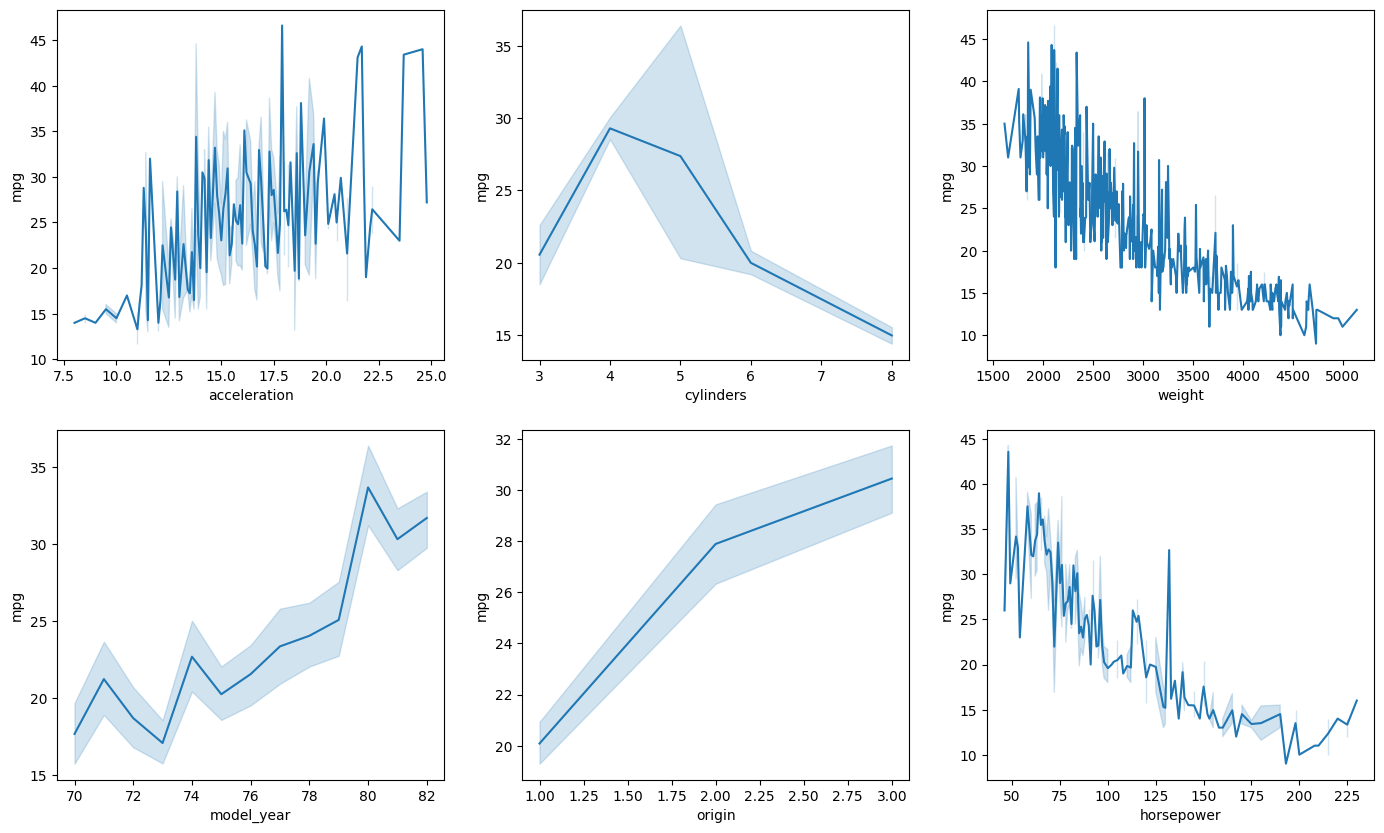

In [43]:
plt.figure(figsize = (17,10))
plt.subplot(231)
sns.lineplot(data = df, x = df.acceleration, y = df.mpg)
plt.subplot(232)
sns.lineplot(data = df, x = df.cylinders, y = df.mpg)
plt.subplot(233)
sns.lineplot(data = df, x = df.weight, y = df.mpg)
plt.subplot(234)
sns.lineplot(data = df, x = df.model_year, y = df.mpg)
plt.subplot(235)
sns.lineplot(data = df, x = df.origin, y = df.mpg)
plt.subplot(236)
sns.lineplot(data = df, x = df.horsepower, y = df.mpg)
plt.show()

In [ ]:
df.car_name.str.split(' ')

In [ ]:
df.car_name.str.split(' ')[0][0]

In [ ]:
df['car_brand'] = df['car_name']
for i in df['car_name'].str.split(' ').index: df['car_brand'][i] = df['car_brand'].str.split(' ')[i][0]
df

In [ ]:
df